# E1 测试：机动强度/频率 OOD（固定噪声）


- 固定噪声：`qc=0.05, sigma_r=0.05`
- 固定数据工况：`mismatch/wpi`，并启用随机机动窗口与随机转向（`randWin/randDir`）
- 训练用基准机动：`turn_length=25, turn_count=6`
- 测试：
  - **E1-a（强度 OOD）**：固定 `K=6`，扫 `L∈{50,25,15}`
  - **E1-b（频率 OOD）**：固定 `L=25`，扫 `K∈{3,6,10}`

对比方法：
- EKF baseline（固定 `Q0,R0`，等价 `δ≡0, β≡1`）
- GRU+EKF joint（加载已训练 ckpt）


## 1) 环境与路径设置

导入依赖、定位项目根目录（包含 `src/`），并选择运行设备（CPU/CUDA）。

In [6]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import torch

# --- locate project root (folder that contains `src/`) ---
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT  :", ROOT)
print("device:", device)


ROOT  : d:\LiLei\Python_projects\GRU_augmented_EKF
device: cuda


## 2) 配置：Checkpoint 与 E1 测试数据集

设置 joint 训练完成的 ckpt 路径，以及 E1-a/E1-b 所需的 5 个 **unique** 测试集

In [7]:
# --- trained checkpoint (joint δ+β, trained on L25 K6) ---
CKPT_JOINT = (
    ROOT
    / Path(
        r"outputs/2026-02-05/22-45-29_E1/outputs/2026-02-05/22-45-29/checkpoints/E1.ckpt"
    )
).resolve()
assert CKPT_JOINT.exists(), f"Checkpoint not found: {CKPT_JOINT}"

# --- E1 datasets (qc=0.05, sigma_r=0.05, mismatch/wpi, randWin/randDir) ---
# E1-a: K=6, L in {50, 25, 15}
# E1-b: L=25, K in {3, 6, 10}
DATASETS: dict[str, Path] = {
    # E1-a
    "E1-a  L50 K6": (ROOT / Path(r"data/raw/trajectory_wpi/trajectory_wpi_N300_T500_qc0.05_sigmar0.05_L50_K6_randWin_randDir.npz")).resolve(),
    "E1-a  L25 K6 (train)": (ROOT / Path(r"data/raw/trajectory_wpi/trajectory_wpi_N300_T500_qc0.05_sigmar0.05_L25_K6_randWin_randDir.npz")).resolve(),
    "E1-a  L15 K6": (ROOT / Path(r"data/raw/trajectory_wpi/trajectory_wpi_N300_T500_qc0.05_sigmar0.05_L15_K6_randWin_randDir.npz")).resolve(),
    # E1-b
    "E1-b  L25 K3": (ROOT / Path(r"data/raw/trajectory_wpi/trajectory_wpi_N300_T500_qc0.05_sigmar0.05_L25_K3_randWin_randDir.npz")).resolve(),
    "E1-b  L25 K10": (ROOT / Path(r"data/raw/trajectory_wpi/trajectory_wpi_N300_T500_qc0.05_sigmar0.05_L25_K10_randWin_randDir.npz")).resolve(),
}
for name, path in DATASETS.items():
    assert path.exists(), f"Dataset not found ({name}): {path}"

print("CKPT_JOINT:", CKPT_JOINT)
print("Datasets:")
for name, path in DATASETS.items():
    print(f"  - {name}: {path.name}")


CKPT_JOINT: D:\LiLei\Python_projects\GRU_augmented_EKF\outputs\2026-02-05\22-45-29_E1\outputs\2026-02-05\22-45-29\checkpoints\E1.ckpt
Datasets:
  - E1-a  L50 K6: trajectory_wpi_N300_T500_qc0.05_sigmar0.05_L50_K6_randWin_randDir.npz
  - E1-a  L25 K6 (train): trajectory_wpi_N300_T500_qc0.05_sigmar0.05_L25_K6_randWin_randDir.npz
  - E1-a  L15 K6: trajectory_wpi_N300_T500_qc0.05_sigmar0.05_L15_K6_randWin_randDir.npz
  - E1-b  L25 K3: trajectory_wpi_N300_T500_qc0.05_sigmar0.05_L25_K3_randWin_randDir.npz
  - E1-b  L25 K10: trajectory_wpi_N300_T500_qc0.05_sigmar0.05_L25_K10_randWin_randDir.npz


## 3) 评估函数：加载 split、运行滤波、统计指标


- 使用 split 文件（`data/processed/<stem>_split.pkl`）得到 test trajectories（若不存在则自动生成并保存）
- 对每个 setting 跑两条线：EKF baseline vs joint GRU+EKF
- 统计：`pos_RMSE / vel_RMSE / mean_NLL / mean_NIS/m / beta_mean/std / delta_rms`

In [8]:
from src.data.components import MeasurementDataset
from src.data.components.splits import (
    create_splits_file_name,
    load_splits_file,
    obtain_tr_val_test_warm_idx,
    save_splits_file,
)
from src.models.lit_module import GruAugmentedEkfLitModule


def ensure_splits(
    dataset_path: Path,
    *,
    seed: int = 0,
    tr_to_test_split: float = 0.9,
    tr_to_val_split: float = 0.8333,
    warm_fraction: float = 0.1,
) -> dict:
    splits_path = create_splits_file_name(dataset_path, splits_name="")
    if splits_path.exists():
        return load_splits_file(splits_path)

    ds = MeasurementDataset(dataset_path)
    train_idx, val_idx, test_idx, warm_idx = obtain_tr_val_test_warm_idx(
        ds,
        tr_to_test_split,
        tr_to_val_split,
        warm_fraction,
        seed=seed,
    )
    splits = {"train": train_idx, "val": val_idx, "test": test_idx, "warm": warm_idx}
    save_splits_file(splits_path, splits)
    return splits


def load_test_split(dataset_path: Path, *, seed: int = 0) -> tuple[np.ndarray, np.ndarray, dict]:
    with np.load(dataset_path, allow_pickle=True) as data:
        X_all = np.asarray(data["X"], dtype=float)
        Y_all = np.asarray(data["Y"], dtype=float)
        meta = {
            "qc": float(np.asarray(data.get("qc", np.nan))),
            "sigma_r": float(np.asarray(data.get("sigma_r", np.nan))),
            "dt": float(np.asarray(data.get("dt", np.nan))),
            "steps": int(np.asarray(data.get("steps", Y_all.shape[1]))),
            "trajectories": int(np.asarray(data.get("trajectories", Y_all.shape[0]))),
            "turn_length": int(np.asarray(data.get("turn_length", 50))),
            "turn_count": int(np.asarray(data.get("turn_count", 3))),
            "random_turn_windows": bool(np.asarray(data.get("random_turn_windows", False))),
            "random_turn_directions": bool(np.asarray(data.get("random_turn_directions", False))),
        }

    splits = ensure_splits(dataset_path, seed=seed)
    test_idx = np.asarray(splits["test"], dtype=int)
    return X_all[test_idx], Y_all[test_idx], meta


def run_filter(model: GruAugmentedEkfLitModule, Y_np: np.ndarray) -> dict[str, np.ndarray]:
    model = model.to(device)
    model.eval()

    obs = torch.as_tensor(Y_np, dtype=torch.float32, device=device)
    B, T, _ = obs.shape
    x0 = torch.zeros(B, model.state_dim, device=device)
    Sigma0 = (
        torch.eye(model.state_dim, device=device)
        .unsqueeze(0)
        .expand(B, -1, -1)
        * float(model.sigma0_scale)
    )
    hidden = (
        model.dynamics.reset_hidden(B, device=device, dtype=obs.dtype)
        if getattr(model.dynamics, "use_gru", False)
        else None
    )
    with torch.no_grad():
        outputs = model.ekf(obs, x0, Sigma0, mask=None, hidden=hidden)
    return {k: v.detach().cpu().numpy() for k, v in outputs.items() if isinstance(v, torch.Tensor)}


def summarize(truth_X: np.ndarray, out: dict[str, np.ndarray]) -> dict[str, float]:
    x_filt = out["x_filt"]
    whitened = out["whitened"]
    logdet = out["logdet_S"]

    nis = np.sum(whitened**2, axis=-1)  # (B, T)
    nll = nis + logdet
    m = int(whitened.shape[-1])

    err = truth_X - x_filt
    pos_err = np.linalg.norm(err[..., :2], axis=-1)  # (B, T)
    pos_err_p95 = float(np.quantile(pos_err, 0.95))
    mse_state = float(np.mean(np.sum(err * err, axis=-1)))
    mse_pos = float(np.mean(np.sum(err[..., :2] * err[..., :2], axis=-1)))
    mse_vel = float(np.mean(np.sum(err[..., 2:4] * err[..., 2:4], axis=-1))) if err.shape[-1] >= 4 else float("nan")

    stats: dict[str, float] = {
        "mse_pos": mse_pos,
        "rmse_pos": float(np.sqrt(mse_pos)),
        "mse_vel": mse_vel,
        "rmse_vel": float(np.sqrt(mse_vel)) if np.isfinite(mse_vel) else float("nan"),
        "mse_state": mse_state,
        "mean_nll": float(np.mean(nll)),
        "mean_nis": float(np.mean(nis)),
        "mean_nis_m": float(np.mean(nis) / float(m)),
        "pos_err_p95": pos_err_p95,
    }
    if "beta" in out:
        beta = out["beta"][..., 0]
        stats["beta_mean"] = float(np.mean(beta))
        stats["beta_std"] = float(np.std(beta))
    if "delta" in out:
        delta = out["delta"]
        stats["delta_rms"] = float(np.sqrt(np.mean(np.sum(delta * delta, axis=-1))))
    return stats


def load_hparams(ckpt_path: Path) -> dict:
    ckpt = torch.load(ckpt_path, map_location="cpu")
    return ckpt.get("hyper_parameters", {})


HP_REF = load_hparams(CKPT_JOINT)
print("HP_REF keys:", len(HP_REF))


def build_ekf_baseline(dataset_path: Path) -> GruAugmentedEkfLitModule:
    hp = dict(HP_REF)
    hp["dataset_path"] = str(dataset_path)
    hp["max_delta"] = 0.0
    hp["dynamics_use_beta_head"] = False
    hp["train_stage"] = "joint"
    hp["dynamics_feature_mode"] = "basic"  # doesn't matter when delta=0
    return GruAugmentedEkfLitModule(**hp)


def load_joint_model(dataset_path: Path) -> GruAugmentedEkfLitModule:
    model = GruAugmentedEkfLitModule.load_from_checkpoint(
        str(CKPT_JOINT),
        map_location="cpu",
        dataset_path=str(dataset_path),
    )
    model.dynamics.use_beta_head = True
    return model


HP_REF keys: 35


## 4) 运行 E1（E1-a / E1-b）并汇总表格

对每个 setting 的 **test split**（默认约 27 条轨迹）分别跑：
- EKF baseline
- joint GRU+EKF（ckpt）

并输出汇总表 + 相对 EKF 的差值（Δ）。

In [9]:
rows = []
outs_for_plot: dict[tuple[str, str], dict[str, np.ndarray]] = {}

for setting, ds_path in DATASETS.items():
    X_test, Y_test, meta = load_test_split(ds_path, seed=0)

    # EKF baseline
    ekf = build_ekf_baseline(ds_path)
    out_ekf = run_filter(ekf, Y_test)
    s_ekf = summarize(X_test, out_ekf)
    outs_for_plot[(setting, "EKF")] = out_ekf

    # joint GRU+EKF
    gru = load_joint_model(ds_path)
    out_gru = run_filter(gru, Y_test)
    s_gru = summarize(X_test, out_gru)
    outs_for_plot[(setting, "GRU+EKF joint")] = out_gru

    for method, stats in [("EKF", s_ekf), ("GRU+EKF joint", s_gru)]:
        rows.append(
            {
                "setting": setting,
                "method": method,
                "turn_length": meta["turn_length"],
                "turn_count": meta["turn_count"],
                "qc": meta["qc"],
                "sigma_r": meta["sigma_r"],
                "pos_RMSE": stats.get("rmse_pos", np.nan),
                "vel_RMSE": stats.get("rmse_vel", np.nan),
                "pos_err_p95": stats.get("pos_err_p95", np.nan),
                "mean_NLL": stats.get("mean_nll", np.nan),
                "mean_NIS/m": stats.get("mean_nis_m", np.nan),
                "beta_mean": stats.get("beta_mean", np.nan),
                "beta_std": stats.get("beta_std", np.nan),
                "delta_rms": stats.get("delta_rms", np.nan),
            }
        )


try:
    import pandas as pd  # type: ignore
    from IPython.display import display  # type: ignore

    df = pd.DataFrame(rows)
    df = df.sort_values(["turn_length", "turn_count", "method"]).reset_index(drop=True)
    display(df)

    # Δ vs EKF baseline (per setting)
    pivot = df.pivot(index="setting", columns="method", values=["pos_RMSE", "vel_RMSE", "pos_err_p95", "mean_NLL", "mean_NIS/m"])  # noqa: E501
    delta = pivot.xs("GRU+EKF joint", axis=1, level=1) - pivot.xs("EKF", axis=1, level=1)
    delta = delta.rename(columns={
        "pos_RMSE": "Δpos_RMSE",
        "vel_RMSE": "Δvel_RMSE",
        "pos_err_p95": "Δpos_err_p95",
        "mean_NLL": "Δmean_NLL",
        "mean_NIS/m": "Δmean_NIS/m",
    })
    display(delta)
except Exception as exc:
    print("Failed to render DataFrame; falling back to plain print.")
    print("Error:", exc)
    for r in rows:
        print(r)


,setting,method,turn_length,turn_count,qc,sigma_r,pos_RMSE,vel_RMSE,pos_err_p95,mean_NLL,mean_NIS/m,beta_mean,beta_std,delta_rms
0,E1-a L15 K6,EKF,15,6,0.05,0.05,0.051009,0.589567,0.108445,-18.403391,1.317505,1.000000,0.000000,0.000000
1,E1-a L15 K6,GRU+EKF joint,15,6,0.05,0.05,0.031555,1.229693,0.059369,-19.340736,1.078912,1.337472,0.053454,0.013200
2,E1-b L25 K3,EKF,25,3,0.05,0.05,0.049860,0.496203,0.106638,-18.810778,1.216817,1.000000,0.000000,0.000000
3,E1-b L25 K3,GRU+EKF joint,25,3,0.05,0.05,0.032477,1.441546,0.060876,-19.382765,1.069607,1.339695,0.047451,0.015181
4,E1-a L25 K6 (train),EKF,25,6,0.05,0.05,0.059766,0.654794,0.120841,-17.932714,1.435138,1.000000,0.000000,0.000000
5,E1-a L25 K6 (train),GRU+EKF joint,25,6,0.05,0.05,0.031230,1.276467,0.057160,-19.355120,1.075517,1.316251,0.060381,0.013625
6,E1-b L25 K10,EKF,25,10,0.05,0.05,0.063780,0.732392,0.125237,-17.565060,1.526973,1.000000,0.000000,0.000000
7,E1-b L25 K10,GRU+EKF joint,25,10,0.05,0.05,0.033559,1.224726,0.062346,-19.308615,1.086885,1.332932,0.056340,0.013247
8,E1-a L50 K6,EKF,50,6,0.05,0.05,0.054744,0.554209,0.106758,-18.509451,1.291097,1.000000,0.000000,0.000000
9,E1-a L50 K6,GRU+EKF joint,50,6,0.05,0.05,0.028726,1.258679,0.052656,-19.428528,1.057202,1.327210,0.052852,0.013419


,Δpos_RMSE,Δvel_RMSE,Δpos_err_p95,Δmean_NLL,Δmean_NIS/m
setting,,,,,
E1-a L15 K6,-0.019455,0.640127,-0.049076,-0.937346,-0.238593
E1-a L25 K6 (train),-0.028536,0.621673,-0.063681,-1.422405,-0.359621
E1-a L50 K6,-0.026018,0.704470,-0.054102,-0.919077,-0.233895
E1-b L25 K10,-0.030221,0.492334,-0.062891,-1.743555,-0.440088
E1-b L25 K3,-0.017383,0.945343,-0.045762,-0.571987,-0.147210


## 5) 可视化

绘制：
- 各 setting 的 `pos_RMSE` 与 `mean_NIS/n`（EKF vs joint）
- 选一个最难 setting（例如 `L25 K10`）展示 mean position error 随时间的曲线（仅用于直观理解）

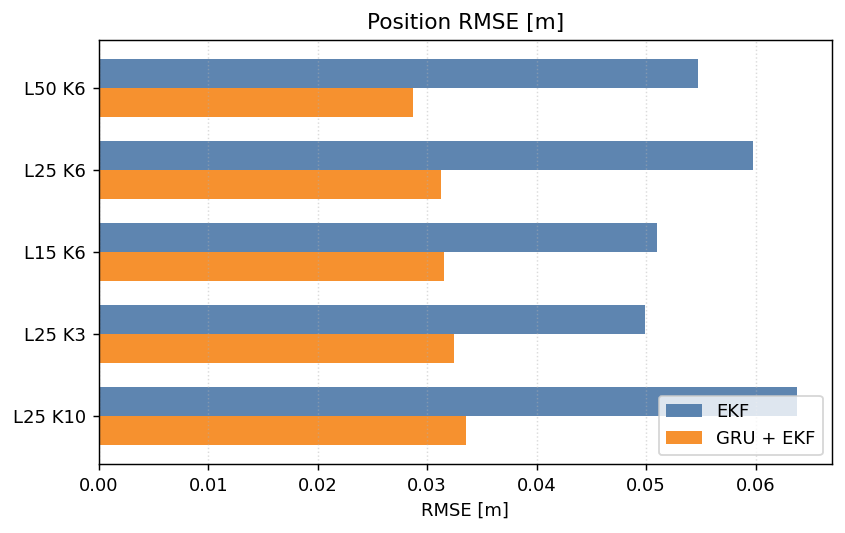

=== Fig02 Precise Statistics (L25 K10) ===
EKF mean error range: 0.0187 -- 0.0708
GRU+EKF mean error range: 0.0195 -- 0.0472
EKF overall mean: 0.0520
GRU+EKF overall mean: 0.0276


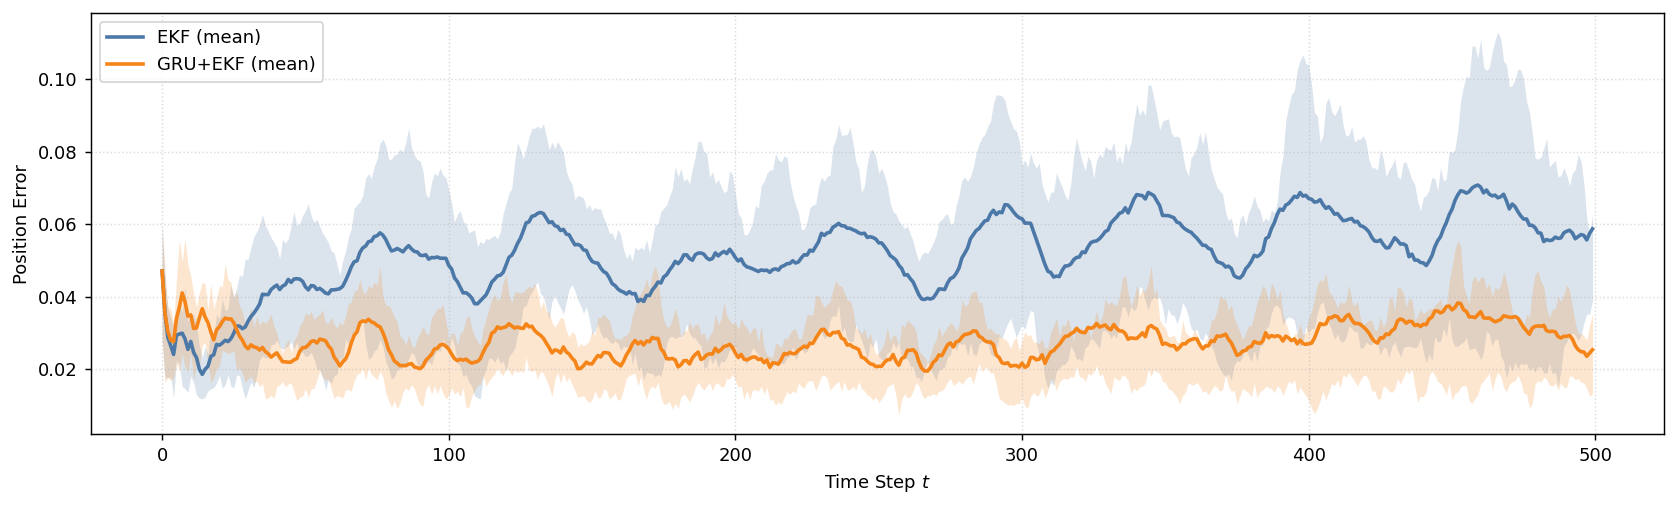

In [10]:
# ---------- 1) grouped comparison: pos_RMSE + mean_NIS/m ----------
df_plot = pd.DataFrame(rows).copy()
order = [
    'E1-a  L50 K6',
    'E1-a  L25 K6 (train)',
    'E1-a  L15 K6',
    'E1-b  L25 K3',
    'E1-b  L25 K10',
]
present_order = [s for s in order if s in set(df_plot['setting'])]
df_plot['setting'] = pd.Categorical(df_plot['setting'], categories=present_order, ordered=True)
df_plot = df_plot.sort_values(['setting', 'method']).reset_index(drop=True)

method_order = ['EKF', 'GRU+EKF joint']
method_disp = {'EKF': 'EKF', 'GRU+EKF joint': 'GRU + EKF'}
def _display_setting(s: str) -> str:
    s = s.replace('E1-a', '').replace('E1-b', '')
    s = ' '.join(s.split())
    if s == 'L25 K6 (train)':
        return 'L25 K6'
    return s
bar_h = 0.35
y = np.arange(len(present_order), dtype=float)
palette = {'EKF': '#4C78A8', 'GRU+EKF joint': '#F58518'}

# RMSE only
metric, title, xlabel, show_legend = ('pos_RMSE', 'Position RMSE [m]', 'RMSE [m]', True)
plt.figure(figsize=(6.6, 4.2), dpi=130)
ax = plt.gca()
piv = df_plot.pivot(index='setting', columns='method', values=metric).reindex(present_order)
for j, m in enumerate(method_order):
    if m not in piv.columns:
        continue
    vals = piv[m].to_numpy(dtype=float)
    ax.barh(y + (j - 0.5) * bar_h, vals, height=bar_h, color=palette.get(m, None), alpha=0.9, label=method_disp.get(m, m))

ax.set_title(title)
ax.grid(True, axis='x', linestyle=':', alpha=0.45)
ax.set_yticks(y)
ax.set_yticklabels([_display_setting(s) for s in present_order])
ax.set_xlabel(xlabel)
ax.invert_yaxis()
if show_legend:
    ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

# ---------- 2) hardest-case temporal curve: mean position error ----------
def _get_err_bt(setting: str, method: str) -> np.ndarray:
    out = outs_for_plot[(setting, method)]
    x_filt = out['x_filt']
    ds_path = DATASETS[setting]
    X_test, _, _ = load_test_split(ds_path, seed=0)
    return np.linalg.norm(X_test[..., :2] - x_filt[..., :2], axis=-1)  # (B, T)

ekf_rmse = df_plot[df_plot['method'] == 'EKF'][['setting', 'pos_RMSE']].dropna()
hard_case = str(ekf_rmse.sort_values('pos_RMSE', ascending=False).iloc[0]['setting']) if not ekf_rmse.empty else present_order[-1]
if hard_case not in DATASETS:
    raise KeyError(f"DATASETS is missing selected hard_case '{hard_case}'.")
err_ekf = _get_err_bt(hard_case, 'EKF')
err_joint = _get_err_bt(hard_case, 'GRU+EKF joint')
t = np.arange(err_ekf.shape[1])

def _band(a: np.ndarray):
    mean = a.mean(axis=0)
    p25 = np.percentile(a, 25, axis=0)
    p75 = np.percentile(a, 75, axis=0)
    return mean, p25, p75

m_e, l_e, u_e = _band(err_ekf)
m_j, l_j, u_j = _band(err_joint)

# Print precise statistics for paper
print(f"=== Fig02 Precise Statistics ({_display_setting(hard_case)}) ===")
print(f'EKF mean error range: {m_e.min():.4f} -- {m_e.max():.4f}')
print(f'GRU+EKF mean error range: {m_j.min():.4f} -- {m_j.max():.4f}')
print(f'EKF overall mean: {m_e.mean():.4f}')
print(f'GRU+EKF overall mean: {m_j.mean():.4f}')

plt.figure(figsize=(13, 4), dpi=130)
plt.plot(t, m_e, color=palette['EKF'], linewidth=2.0, label='EKF (mean)')
plt.fill_between(t, l_e, u_e, color=palette['EKF'], alpha=0.20, linewidth=0)
plt.plot(t, m_j, color=palette['GRU+EKF joint'], linewidth=2.0, label='GRU+EKF (mean)')
plt.fill_between(t, l_j, u_j, color=palette['GRU+EKF joint'], alpha=0.20, linewidth=0)
plt.xlabel('Time Step $t$')
plt.ylabel('Position Error')
plt.grid(True, linestyle=':', alpha=0.45)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()



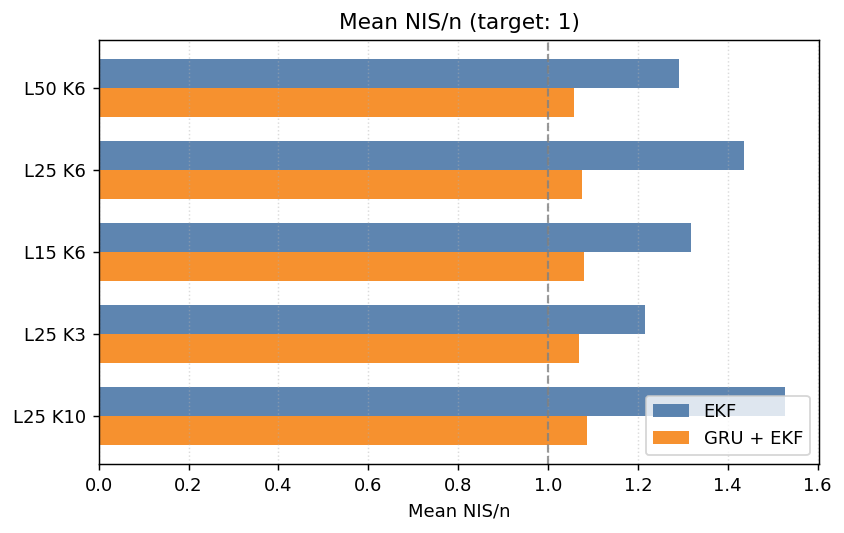

In [11]:
# ---------- 1) grouped comparison: pos_RMSE + mean_NIS/m ----------
df_plot = pd.DataFrame(rows).copy()
order = [
    'E1-a  L50 K6',
    'E1-a  L25 K6 (train)',
    'E1-a  L15 K6',
    'E1-b  L25 K3',
    'E1-b  L25 K10',
]
present_order = [s for s in order if s in set(df_plot['setting'])]
df_plot['setting'] = pd.Categorical(df_plot['setting'], categories=present_order, ordered=True)
df_plot = df_plot.sort_values(['setting', 'method']).reset_index(drop=True)

method_order = ['EKF', 'GRU+EKF joint']
method_disp = {'EKF': 'EKF', 'GRU+EKF joint': 'GRU + EKF'}
def _display_setting(s: str) -> str:
    s = s.replace('E1-a', '').replace('E1-b', '')
    s = ' '.join(s.split())
    if s == 'L25 K6 (train)':
        return 'L25 K6'
    return s
bar_h = 0.35
y = np.arange(len(present_order), dtype=float)
palette = {'EKF': '#4C78A8', 'GRU+EKF joint': '#F58518'}

# NIS only
metric, title, xlabel, show_legend = ('mean_NIS/m', 'Mean NIS/n (target: 1)', 'Mean NIS/n', True)
plt.figure(figsize=(6.6, 4.2), dpi=130)
ax = plt.gca()
piv = df_plot.pivot(index='setting', columns='method', values=metric).reindex(present_order)
for j, m in enumerate(method_order):
    if m not in piv.columns:
        continue
    vals = piv[m].to_numpy(dtype=float)
    ax.barh(y + (j - 0.5) * bar_h, vals, height=bar_h, color=palette.get(m, None), alpha=0.9, label=method_disp.get(m, m))

ax.set_title(title)
ax.grid(True, axis='x', linestyle=':', alpha=0.45)
ax.axvline(1.0, color='gray', linestyle='--', linewidth=1.2, alpha=0.8)
ax.set_yticks(y)
ax.set_yticklabels([_display_setting(s) for s in present_order])
ax.set_xlabel(xlabel)
ax.invert_yaxis()
if show_legend:
    ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()
